In [13]:
import time
import h5py
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [16]:
import h5py
import numpy as np
import yaml
import matplotlib.pyplot as plt

# --- config ---
base = '/sdf/data/lcls/ds/rix/'
exp  = 'rix101231825'
run  = 140
fyaml_path = '../roi_input.yml'         # swap to ferufe/roi_input_ferufe.yml if needed
n_show     = -1                       # subsample for speed
# fname = f'{base}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base}/{exp}/hdf5/smalldata/run140_th100_tha480/{exp}_Run{run:04d}.h5' 

fname_dr   = f'{base}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'          # original
fname_raw  = f'{base}/{exp}/hdf5/smalldata/run140_th100_tha480/{exp}_Run{run:04d}.h5'           # no droplet

with h5py.File(fname_dr, 'r') as h5:
    proj_dr = h5['intg/axis_svls/droplet_dense_curve_corr_pj_ax_1_data'][:]
with h5py.File(fname_raw, 'r') as h5:
    proj_nd = h5['intg/axis_svls/curve_corr_pj_ax_1_data'][:]          # adjust key from h5ls
    # proj_nd = h5['intg/axis_svls/droplet_dense_curve_corr_pj_ax_1_data'][:]
svls_sum_dr = proj_dr.sum(axis=1)
svls_sum_nd = proj_nd.sum(axis=1)




with open(fyaml_path) as f:
    cfg = yaml.safe_load(f)
fim0_cfg = cfg['fim0']; fim1_cfg = cfg['fim1']

print(fname)


with h5py.File(fname, 'r') as h5:
    print(h5['Sums'].keys())
    print(h5['intg'].keys())
    fim0_wf = h5['intg']['axis_svls']['det_rix_fim0_sum_full_area'][:n_show]   # (shots, channels, samples)
    fim1_wf = h5['intg']['axis_svls']['det_rix_fim1_sum_full_area'][:n_show]
    print(f'fim0 shape: {fim0_wf.shape}, fim1 shape: {fim1_wf.shape}')


with h5py.File(fname_dr, 'r') as h5:
    g       = h5['intg/axis_svls']
    count   = g['count'][:].squeeze()
    monoenc = g['mono_hrencoder_sum_value'][:].squeeze()
    fim0_wf = g['det_rix_fim0_sum_full_area'][:]
    fim1_wf = g['det_rix_fim1_sum_full_area'][:]
    try:
        ek, ea = cfg['epics']['key'], cfg['epics']['attr']['MONO_premirror_pitch']
        premirror = get_premirror_pitch(h5[f'/{ek}/{ea}'][:, 1])
    except Exception:
        premirror = 144506

# ---- count mask: keep frames with the expected number of shots ----
mode_c = st.mode(count, keepdims=False)[0]
cmask  = (count > mode_c-1) & (count < mode_c+1)

# ---- I0 from FIM0 + FIM1, channels 1-4, sig [65:75], bg [0:60] ----
def i0_sum(wf, sig=slice(65, 75), bg=slice(0, 60), channels=(0, 1, 2, 3)):
    ch  = list(channels)
    base = wf[:, ch, bg].mean(axis=-1, keepdims=True)
    return np.abs(wf[:, ch, sig] - base).sum(axis=(-2, -1))

I0_i = i0_sum(fim0_wf) + i0_sum(fim1_wf)

# ---- per-shot mono energy ----
mc = next((np.asarray(r)[2:4] for r in cfg['mono_calib'] if run > r[0] and run < r[1]), None)
assert mc is not None, f'no mono_calib row matches run {run}'
energy_eV = mono_energy(np.polyval(mc, monoenc/count), premirror, fname='../mono_calib.yml')

print(f'{len(count)} shots, mode count = {mode_c}, '
      f'kept by cmask: {cmask.sum()} ({100*cmask.mean():.1f}%)')
print(f'I0: median = {np.median(I0_i):.2e}, range = [{I0_i.min():.2e}, {I0_i.max():.2e}]')
print(f'energy: range = [{np.nanmin(energy_eV):.2f}, {np.nanmax(energy_eV):.2f}] eV')


# # --- plot: mean ± std per channel, with bg_roi (gray) + signal ROI (red) overlaid ---
# fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True)
# nsamp = fim0_wf.shape[-1]; x = np.arange(nsamp)
# rng = np.random.default_rng(0)

# for det_name, wf, det_cfg, axrow in [('fim0', fim0_wf, fim0_cfg, axes[0]),
#                                       ('fim1', fim1_wf, fim1_cfg, axes[1])]:
#     channels, roi, bg_roi = det_cfg['channels'], det_cfg['roi'], det_cfg['bg_roi']
#     for i, c in enumerate(channels):
#         ax = axrow[i]; ch = c - 1   # yaml is 1-indexed
#         m  = wf[:, ch, :].mean(0); s = wf[:, ch, :].std(0)
#         # individual shots (faint)
#         for j in rng.choice(wf.shape[0], 30, replace=False):
#             ax.plot(x, wf[j, ch, :], color='steelblue', alpha=0.1, lw=0.5)
#         ax.plot(x, m, 'k', lw=1.3, label='mean')
#         # ax.fill_between(x, m-s, m+s, color='k', alpha=0.15, label='±1σ')
#         ax.axvspan(bg_roi[0], bg_roi[1], color='gray', alpha=0.25, label='bg_roi')
#         ax.axvspan(roi[i][0], roi[i][1], color='red',  alpha=0.20, label='signal ROI')
#         ax.set_title(f'{det_name} ch{c} (idx {ch})'); ax.set_xlabel('sample')
#         if i == 0: ax.legend(fontsize=8, loc='best')
# plt.tight_layout(); plt.show()

/sdf/data/lcls/ds/rix//rix101231825/hdf5/smalldata/run140_th100_tha480/rix101231825_Run0140.h5
<KeysViewHDF5 ['c_atmopal_calib', 'c_piranha_calib', 'det_crix_w8_calib', 'det_rix_fim0_calib', 'det_rix_fim1_calib', 'fzp_piranha_calib']>
<KeysViewHDF5 ['axis_svls', 'timestamp']>
fim0 shape: (29152, 8, 256), fim1 shape: (29152, 8, 256)
29153 shots, mode count = 335, kept by cmask: 15695 (53.8%)
I0: median = 6.76e+06, range = [3.00e+05, 1.47e+07]
energy: range = [695.44, 711.64] eV


shots: 29153  (matches across both files)
mean SVLS — dropletted: 1.42e+03, no droplet: 1.13e+06, ratio nd/dr: 795.85

1120 shots in 700.00 ± 0.50 eV window


/lscratch/yzy25/tmp/ipykernel_1415412/32355905.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axx.legend(fontsize=9, loc='upper left')


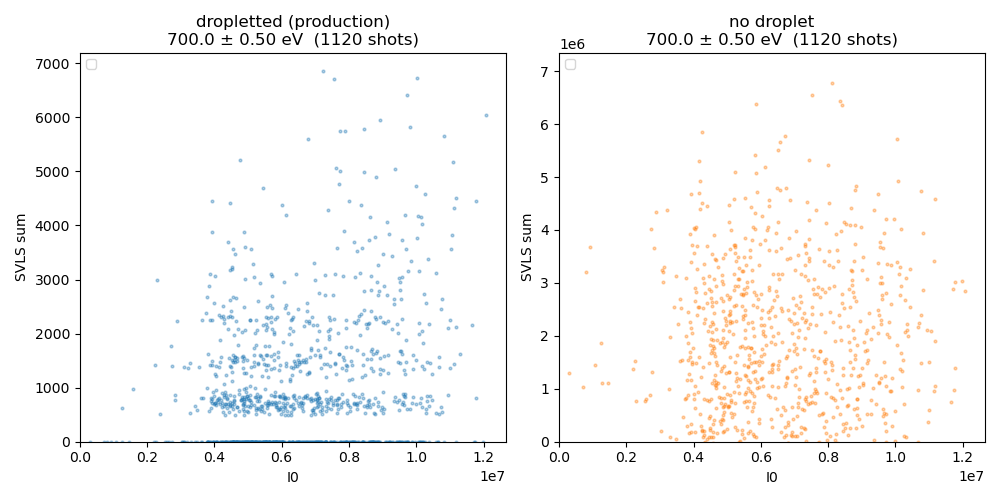

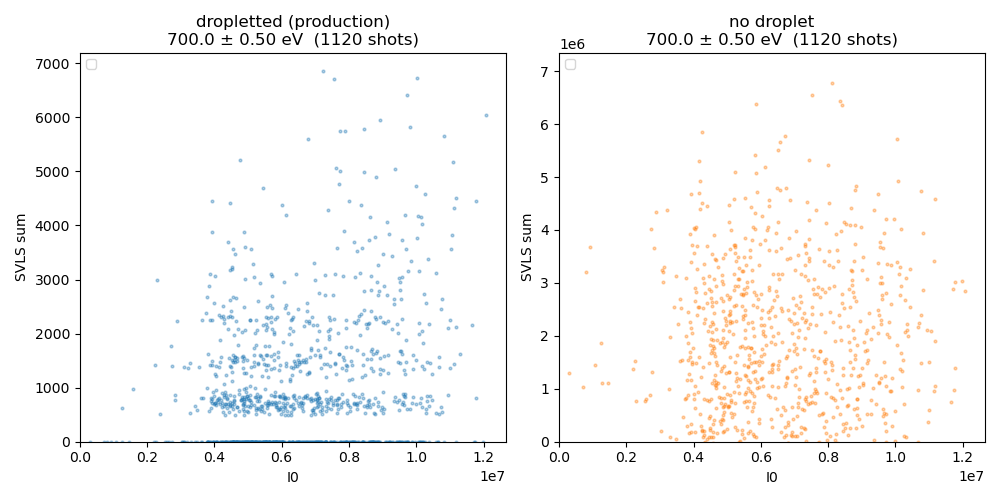

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already have in scope from the dropletted SMD:
#   energy_eV, I0_i, cmask   — per-shot, same length as svls_sum_dr / svls_sum_nd
# and from above:
#   svls_sum_dr, svls_sum_nd

# Quick sanity check
assert len(svls_sum_dr) == len(svls_sum_nd) == len(energy_eV), (
    f'shot count mismatch: dr={len(svls_sum_dr)}, nd={len(svls_sum_nd)}, E={len(energy_eV)}'
)
print(f'shots: {len(svls_sum_dr)}  (matches across both files)')
print(f'mean SVLS — dropletted: {svls_sum_dr.mean():.3g}, no droplet: {svls_sum_nd.mean():.3g}, '
      f'ratio nd/dr: {svls_sum_nd.mean()/svls_sum_dr.mean():.2f}')

# ============================================================
#  CHOOSE THE ENERGY TO INSPECT
# ============================================================
E_focus = 700
E_width = 1.0
# ============================================================

m = cmask & (energy_eV >= E_focus - E_width/2) & (energy_eV < E_focus + E_width/2)
n_focus = int(m.sum())
print(f'\n{n_focus} shots in {E_focus:.2f} ± {E_width/2:.2f} eV window')

if n_focus < 10:
    print('⚠ too few shots — widen E_width or pick a different E_focus')
else:
    I0 = I0_i[m]
    SV_dr, SV_nd = svls_sum_dr[m], svls_sum_nd[m]

    # ---- side-by-side scatter at the focus energy ----
    fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
    for axx, SV, label, dot_color in [
        (ax[0], SV_dr, 'dropletted (production)', 'tab:blue'),
        (ax[1], SV_nd, 'no droplet',              'tab:orange'),
    ]:
        s, b = np.polyfit(I0, SV, 1)
        r    = np.corrcoef(I0, SV)[0, 1]
        axx.plot(I0, SV, '.', ms=4, alpha=0.35, color=dot_color)
        xx = np.linspace(0, I0.max(), 100)
        # axx.plot(xx, s*xx + b, 'r-',  lw=1.5, label=f'fit: {s:.3g}·I0 + {b:.3g}\nr = {r:.3f}')
        # axx.plot(xx, s*xx,     'g--', lw=1.2, alpha=0.7, label='through origin')
        axx.set_xlim(0); axx.set_ylim(bottom=0)
        axx.set_xlabel('I0'); axx.set_ylabel('SVLS sum')
        axx.set_title(f'{label}\n{E_focus:.1f} ± {E_width/2:.2f} eV  ({n_focus} shots)')
        axx.legend(fontsize=9, loc='upper left')
    plt.tight_layout(); plt.show()

# ============================================================
#  Per-bin r and slope across the full scan, so the focus window
#  isn't judged in isolation
# ============================================================
def per_bin(E, I0, SV, mask, ebin_width=1.0, min_n=10):
    E, I0, SV = E[mask], I0[mask], SV[mask]
    ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, ebin_width)
    ecen  = 0.5 * (ebins[:-1] + ebins[1:])
    idx   = np.digitize(E, ebins)
    n     = np.array([(idx == i+1).sum() for i in range(len(ecen))])
    r     = np.full(len(ecen), np.nan)
    slope = np.full(len(ecen), np.nan)
    for i in range(len(ecen)):
        msk = idx == i+1
        if msk.sum() >= min_n:
            slope[i], _ = np.polyfit(I0[msk], SV[msk], 1)
            r[i] = np.corrcoef(I0[msk], SV[msk])[0, 1]
    return ecen, n, r, slope

ecen_dr, n_dr, r_dr, sl_dr = per_bin(energy_eV, I0_i, svls_sum_dr, cmask)
ecen_nd, n_nd, r_nd, sl_nd = per_bin(energy_eV, I0_i, svls_sum_nd, cmask)

# fig, ax2 = plt.subplots(1, 2, figsize=(10, 5))

# ax2[0].plot(ecen_dr, r_dr, 'o-', label='dropletted', color='tab:blue')
# ax2[0].plot(ecen_nd, r_nd, 's-', label='no droplet', color='tab:orange', alpha=0.8)
# # ax2[0].axhline(0.9, ls='--', color='r',    alpha=0.4)
# # ax2[0].axhline(0,   ls=':',  color='gray', alpha=0.5)
# ax2[0].axvspan(E_focus - E_width/2, E_focus + E_width/2, alpha=0.15, color='tab:gray',
#                label=f'focus ({E_focus:.1f} eV)')
# ax2[0].set_ylim(-0.5, 1)
# ax2[0].set_xlabel('energy (eV)'); ax2[0].set_ylabel('Pearson r (SVLS vs I0)')
# ax2[0].set_title('per-bin linearity'); ax2[0].legend(fontsize=9)

# ax2[1].plot(ecen_dr, sl_dr/np.nanmean(sl_dr), 'o-', label='dropletted', color='tab:blue')
# ax2[1].plot(ecen_nd, sl_nd/np.nanmean(sl_nd), 's-', label='no droplet', color='tab:orange', alpha=0.8)
# ax2[1].axvspan(E_focus - E_width/2, E_focus + E_width/2, alpha=0.15, color='tab:gray')
# ax2[1].set_xlabel('energy (eV)'); ax2[1].set_ylabel('slope / mean(slope)')
# ax2[1].set_title('per-bin normalized slope'); ax2[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

1123 shots in 704.50 ± 0.50 eV


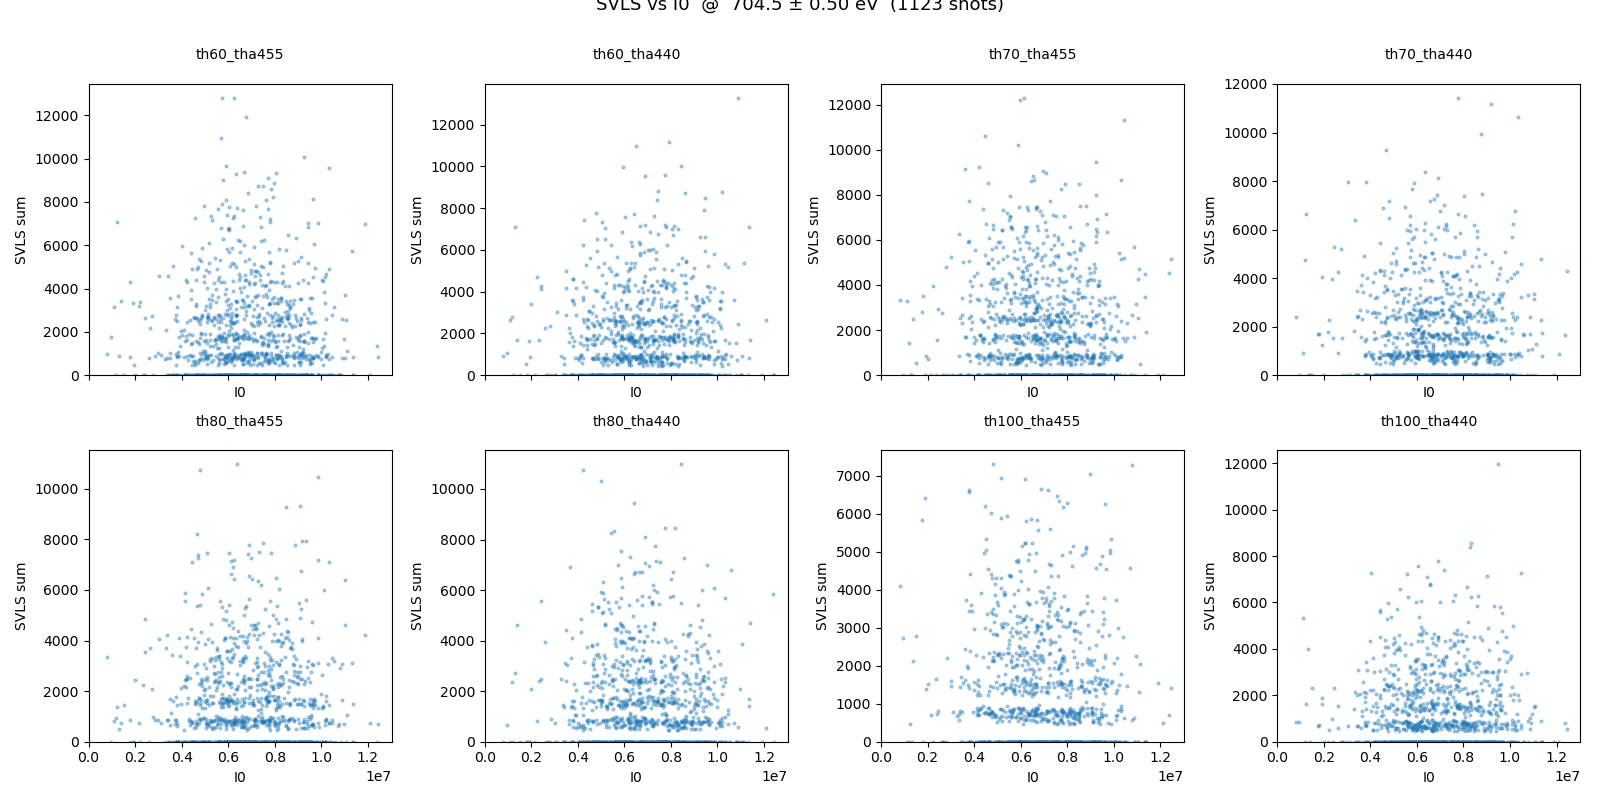

In [26]:
import re

variant_tags = ['th60_tha455',  'th60_tha440',
                'th70_tha455',  'th70_tha440',
                'th80_tha455',  'th80_tha440',
                'th100_tha455', 'th100_tha440']

E_focus = 704.5
E_width = 1.0

m  = cmask & (energy_eV >= E_focus - E_width/2) & (energy_eV < E_focus + E_width/2)
I0 = I0_i[m]
n_focus = int(m.sum())
print(f'{n_focus} shots in {E_focus:.2f} ± {E_width/2:.2f} eV')

def load_sum(fname, key='droplet_dense_curve_corr_pj_ax_1_data'):
    with h5py.File(fname, 'r') as h5:
        return h5[f'intg/axis_svls/{key}'][:].sum(axis=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
axes = axes.ravel()

for i, tag in enumerate(variant_tags):
    path = f'{base}/{exp}/hdf5/smalldata/run{run}_{tag}/{exp}_Run{run:04d}.h5'
    try:
        SV_all = load_sum(path)
    except Exception as e:
        axes[i].set_title(f'{tag}\n(load failed: {e})', fontsize=10)
        continue
    if len(SV_all) != len(I0_i):
        axes[i].set_title(f'{tag}\nshot mismatch ({len(SV_all)} vs {len(I0_i)})', fontsize=10)
        continue

    SV = SV_all[m]
    s, b = np.polyfit(I0, SV, 1)
    r    = np.corrcoef(I0, SV)[0, 1]

    axes[i].plot(I0, SV, '.', ms=4, alpha=0.35, color='tab:blue')
    xx = np.linspace(0, I0.max(), 100)
    # axes[i].plot(xx, s*xx + b, 'r-', lw=1.5)
    axes[i].set_xlim(0); axes[i].set_ylim(bottom=0)
    axes[i].set_xlabel('I0'); axes[i].set_ylabel('SVLS sum')
    axes[i].set_title(f'{tag}\n', fontsize=10)

plt.suptitle(f'SVLS vs I0  @  {E_focus:.1f} ± {E_width/2:.2f} eV  ({n_focus} shots)',
             fontsize=13, y=1.005)
plt.tight_layout(); plt.show()

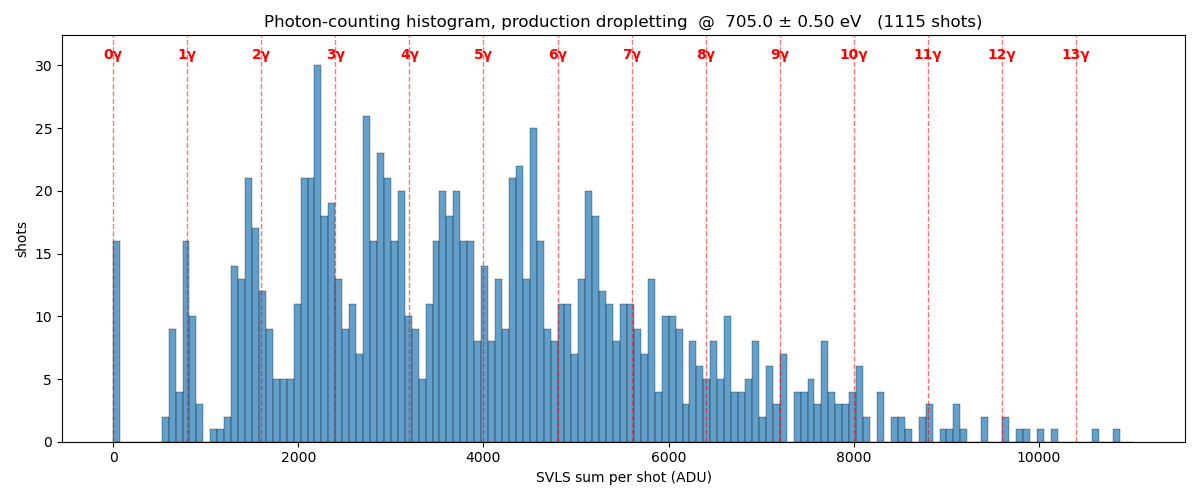

shots in 0γ band ([0, 400]):       16
shots in 1γ band ([400, 1200]):  46
shots in 2γ band ([1200, 2000]):  111
shots in 3γ band ([2000, 2800]):  182
shots in 4γ band ([2800, 3600]):  163
shots in 5γ band ([3600, 4400]):  158
shots above 5γ:                  439
mean SVLS sum:                   4008.3  →  λ ≈ 5.01 photons/shot


In [27]:
E_focus = 705.0
E_width = 1.0

m  = cmask & (energy_eV >= E_focus - E_width/2) & (energy_eV < E_focus + E_width/2)
SV = svls_sum_dr[m]      # production dropletted, this is where peaks should be cleanest

PEAK_1PH = 800           # ADU per photon (from your prior validation: 1γ peak ~800)

fig, ax = plt.subplots(figsize=(12, 5))

# Fine bins to resolve the peaks (~10× narrower than peak separation)
bins = np.arange(0, np.nanpercentile(SV, 99.5) + 75, 75)
counts, edges, _ = ax.hist(SV, bins=bins, color='tab:blue', alpha=0.7,
                            edgecolor='k', linewidth=0.3)

# Mark expected N-photon positions
ymax = counts.max() * 1.08
for n in range(0, int(edges[-1] / PEAK_1PH) + 1):
    ax.axvline(n * PEAK_1PH, ls='--', color='red', alpha=0.55, lw=1)
    ax.text(n * PEAK_1PH, ymax * 0.97, f'{n}γ',
            ha='center', va='top', color='red', fontsize=10, weight='bold')

ax.set_ylim(0, ymax)
ax.set_xlabel('SVLS sum per shot (ADU)')
ax.set_ylabel('shots')
ax.set_title(f'Photon-counting histogram, production dropletting  @  '
             f'{E_focus:.1f} ± {E_width/2:.2f} eV   ({len(SV)} shots)')
plt.tight_layout(); plt.show()

# Quick Poisson-mean estimate from band populations
print(f'shots in 0γ band ([0, {PEAK_1PH//2}]):       '
      f'{((SV >= 0)         & (SV < PEAK_1PH * 0.5 )).sum()}')
for n in range(1, 6):
    lo, hi = (n - 0.5) * PEAK_1PH, (n + 0.5) * PEAK_1PH
    print(f'shots in {n}γ band ([{int(lo)}, {int(hi)}]):  '
          f'{((SV >= lo) & (SV < hi)).sum()}')
print(f'shots above 5γ:                  {(SV >= 5.5 * PEAK_1PH).sum()}')
print(f'mean SVLS sum:                   {SV.mean():.1f}  '
      f'→  λ ≈ {SV.mean()/PEAK_1PH:.2f} photons/shot')

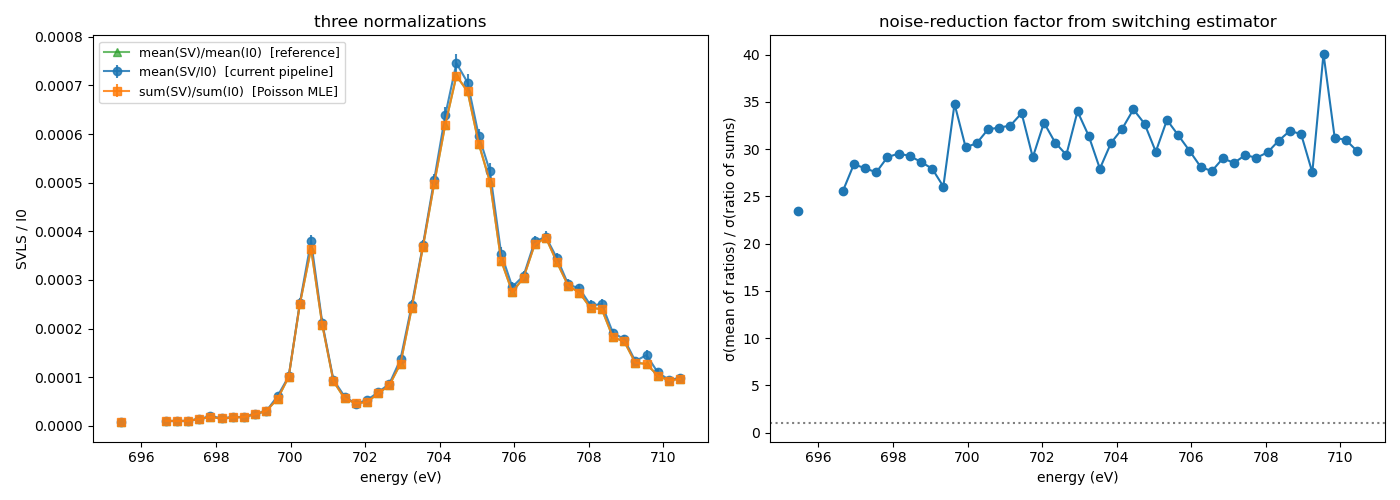

In [30]:
def bin_three_ways(E, I0, SV, mask, ebin_width=1.0, min_n=5):
    E, I0, SV = E[mask], I0[mask], SV[mask]
    ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, ebin_width)
    ecen  = 0.5 * (ebins[:-1] + ebins[1:])
    idx   = np.digitize(E, ebins)

    mor_mean   = np.full(len(ecen), np.nan)   # mean of ratios: mean(SV/I0)
    mor_sem    = np.full(len(ecen), np.nan)
    ros_mean   = np.full(len(ecen), np.nan)   # ratio of sums: sum(SV)/sum(I0)
    ros_sem    = np.full(len(ecen), np.nan)
    rom_mean   = np.full(len(ecen), np.nan)   # ratio of means: mean(SV)/mean(I0)
    n          = np.zeros(len(ecen), int)

    norm = SV / I0
    for i in range(len(ecen)):
        m = idx == i+1
        if m.sum() >= min_n:
            n[i] = m.sum()
            mor_mean[i] = np.mean(norm[m])
            mor_sem[i]  = np.std(norm[m]) / np.sqrt(n[i])

            ssv, si0 = SV[m].sum(), I0[m].sum()
            ros_mean[i] = ssv / si0
            ros_sem[i]  = np.sqrt(ssv) / si0           # Poisson on numerator

            rom_mean[i] = SV[m].mean() / I0[m].mean()
    return ecen, n, mor_mean, mor_sem, ros_mean, ros_sem, rom_mean

ecen, n, mor_m, mor_e, ros_m, ros_e, rom_m = bin_three_ways(
    energy_eV, I0_i, svls_sum_dr, cmask, ebin_width=0.3)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# absolute curves
ax[0].errorbar(ecen, mor_m, yerr=mor_e, fmt='o-', label='mean(SV/I0)  [current pipeline]', alpha=0.85)
ax[0].errorbar(ecen, ros_m, yerr=ros_e, fmt='s-', label='sum(SV)/sum(I0)  [Poisson MLE]', alpha=0.85)
ax[0].plot(ecen, rom_m, '^-', label='mean(SV)/mean(I0)  [reference]', alpha=0.7)
ax[0].set_xlabel('energy (eV)'); ax[0].set_ylabel('SVLS / I0')
ax[0].set_title('three normalizations'); ax[0].legend(fontsize=9)

# ratio of error bars (how much noise reduction the MLE gives you)
ax[1].plot(ecen, mor_e / ros_e, 'o-')
ax[1].axhline(1, ls=':', color='gray')
ax[1].set_xlabel('energy (eV)')
ax[1].set_ylabel('σ(mean of ratios) / σ(ratio of sums)')
ax[1].set_title('noise-reduction factor from switching estimator')
plt.tight_layout(); plt.show()

check andor_dir

/sdf/data/lcls/ds/rix//rix101231825/hdf5/smalldata/rix101231825_Run0140.h5
piranha-ish keys: ['c_piranha_sum_full_area', 'fzp_piranha_sum_full_area']
fzp_piranha shape: (29153, 2048)
on frames: 14576   off frames: 14577


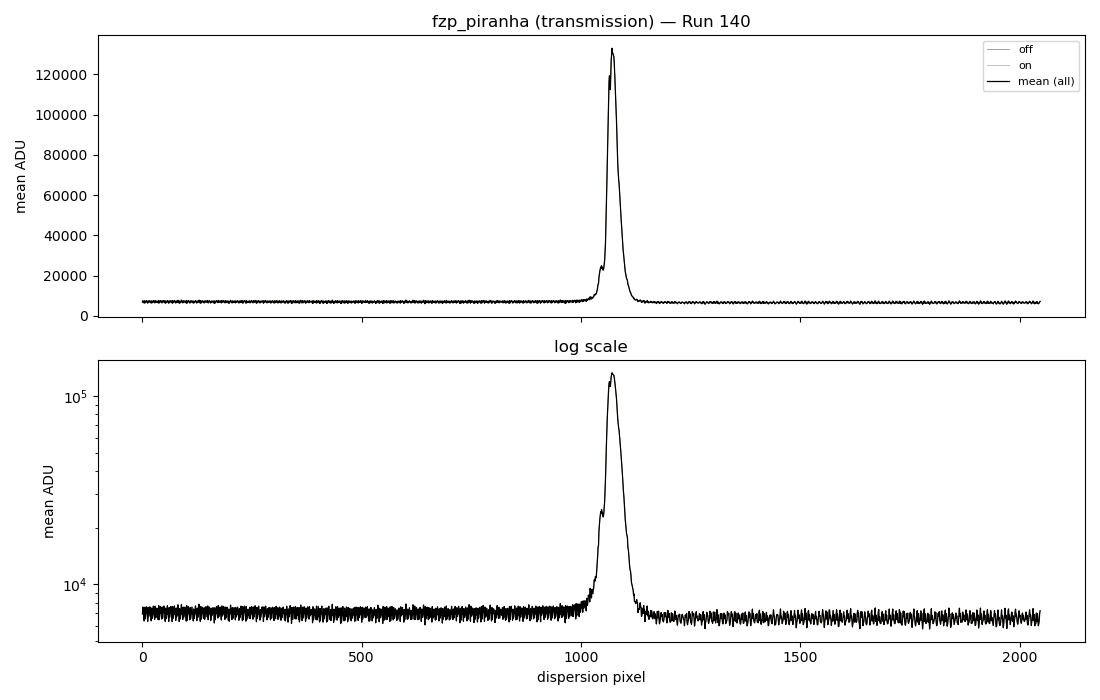

In [14]:
import h5py
import numpy as np
import yaml
# import matplotlib.pyplot as plt

# --- config (same header) ---
base = '/sdf/data/lcls/ds/rix/'
exp  = 'rix101231825'
run  = 140
fname = f'{base}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'   # standard smd file

# fzp_piranha is new -> not in the yaml yet. Set these once you see where the beam sits.
roi        = None        # e.g. [start, stop] over the dispersed transmitted beam
offset_roi = None        # e.g. [start, stop] on flat dark, off the beam
print(fname)

with h5py.File(fname, 'r') as h5:
    g = h5['intg']['axis_svls']
    print('piranha-ish keys:', [k for k in g.keys() if 'piranha' in k.lower()])
    fzp = g['fzp_piranha_sum_full_area'][:].astype(float)     # (frames, pixels), summed over the window
    evc = g['timing_sum_eventcodes'][:]
    cnt = g['count'][:].astype(float)
print(f'fzp_piranha shape: {fzp.shape}')

# laser on/off split (same rule as the proc code)
exp_cnt = np.bincount(cnt.astype(int)).argmax()
on  = (evc[:, 273] / exp_cnt) > 0.5
off = (evc[:, 272] / exp_cnt) > 0.5
print(f'on frames: {on.sum()}   off frames: {off.sum()}')

if fzp.ndim == 2:                                   # line camera -> (frames, dispersion)
    spec     = np.nanmean(fzp, 0)
    spec_on  = np.nanmean(fzp[on],  0) if on.any()  else None
    spec_off = np.nanmean(fzp[off], 0) if off.any() else None
    x = np.arange(spec.size)

    fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for a in ax:
        if spec_off is not None: a.plot(x, spec_off, color='tab:blue',   lw=0.6, alpha=0.7, label='off')
        if spec_on  is not None: a.plot(x, spec_on,  color='tab:orange', lw=0.6, alpha=0.7, label='on')
        a.plot(x, spec, 'k', lw=0.9, label='mean (all)')
        if roi        is not None: a.axvspan(roi[0], roi[1],               color='red',  alpha=0.15, label=f'roi {roi}')
        if offset_roi is not None: a.axvspan(offset_roi[0], offset_roi[1], color='gray', alpha=0.4,  label=f'offset_roi {offset_roi}')
        a.set_ylabel('mean ADU')
    ax[0].legend(fontsize=8); ax[0].set_title(f'fzp_piranha (transmission) — Run {run}')
    ax[1].set_yscale('log'); ax[1].set_xlabel('dispersion pixel'); ax[1].set_title('log scale')
    plt.tight_layout(); plt.show()

    if roi is not None:
        print(f'signal inside roi  : {100*spec[roi[0]:roi[1]].sum()/spec.sum():.2f}%')
    if offset_roi is not None:
        print(f'mean in offset_roi : {spec[offset_roi[0]:offset_roi[1]].mean():.4g}   (pedestal you subtract)')
else:
    print(f'unexpected ndim={fzp.ndim}; piranha should be a 1-D line camera -> (frames, pixels). Inspect before trusting.')

In [9]:
ped     = np.median(spec)                      # camera pedestal (~7000)
sig     = spec - ped
peak_px = sig.argmax()
above   = np.where(sig > 0.05 * sig.max())[0]  # beam = >5% of peak height above pedestal
lo, hi  = above.min(), above.max()
print(f'pedestal ~{ped:.0f} ADU,  peak at pixel {peak_px},  beam spans [{lo}, {hi}]')
print(f'suggested roi: [{lo-10}, {hi+10}]')

pedestal ~6883 ADU,  peak at pixel 1071,  beam spans [1038, 1110]
suggested roi: [1028, 1120]
